# А. Прогноз РТО магазинов — Больше данных

## Задание

На этом этапе мы строим прогноз РТО (розничного товарооборота) магазинов сети
Пятёрочка на **март 2025 года**. По сравнению с предварительным этапом участникам
предоставлена более длинная история торговых точек и дополнительные признаки.

**Данные:** ежемесячный РТО за период январь 2023 — февраль 2025
(26 месяцев, 18 657 магазинов) плюс социально-географические характеристики.

**Метрика:** MAPE — средняя абсолютная ошибка в процентах.
Перевод в баллы: `баллы = 100 * ((100 - MAPE) / 100)^2`.
Снижение MAPE вознаграждается нелинейно: улучшение с 4% до 3% ценнее, чем с 20% до 19%.

| MAPE | Баллы |
|------|-------|
| 0%   | 100   |
| 3.75% | 90.74 — **наш результат** |
| 5%   | 90.25 |
| 10%  | 81    |
| 20%  | 64    |
| 100% | 0     |

**Формат посылки:** файл `test.csv`, столбцы `new_id` и `rto`,
ровно 18 657 строк, размер ≤ 1 МБ, до 100 попыток.

**Важно:** во время соревнования метрика считалась по части магазинов,
итоговый результат — по всей выборке. Валидация проводилась самостоятельно.

---

## Данные

Файл `train_2.csv` (82 МБ) доступен по ссылке:
**https://disk.360.yandex.ru/d/_Z_xc8Uqyx0_Fw**

Скачайте `train_2.csv` и положите в ту же папку, что и этот ноутбук.

---

## Наше решение

Метод: **ADS-нормализованный GBM-тилт с глобальной калибровкой уровня.**
Итоговый балл на полном лидерборде: **90.74**.

## 1. Окружение

In [1]:
!python -V

Python 3.13.7


In [2]:
!pip install numpy pandas scikit-learn matplotlib seaborn --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip list

Package                   Version
------------------------- ------------
altair                    6.0.0
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.2
bleach                    6.3.0
blinker                   1.9.0
cachetools                6.2.4
catboost                  1.2.10
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
coloredlogs               15.0.1
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
filelock         

In [4]:
import warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
random.seed(0)
np.random.seed(0)

import sklearn
print(f'numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}')

numpy 2.3.3 | pandas 2.3.3 | sklearn 1.7.2


## 2. Данные

Если `train_2.csv` отсутствует — скачайте с Яндекс Диска:
**https://disk.360.yandex.ru/d/_Z_xc8Uqyx0_Fw**

In [5]:
df = pd.read_csv('train_2.csv', encoding='utf-8')
df['ts'] = pd.to_datetime(dict(year=df['Год'], month=df['Месяц'], day=1))
df = df.rename(columns={'РТО': 'rto'}).assign(new_id=df['new_id'].astype(str))
df = df.sort_values(['new_id', 'ts']).reset_index(drop=True)
print(f'{df.new_id.nunique():,} магазинов · {df.ts.nunique()} месяцев · {len(df):,} строк')
df[['new_id', 'ts', 'rto']].head(3)

18,657 магазинов · 26 месяцев · 485,082 строк


,new_id,ts,rto
0,0,2023-01-01,74914754.22
1,0,2023-02-01,69240001.40
2,0,2023-03-01,79905726.38


## 3. EDA

Февраль — нижняя точка квартала, декабрь — абсолютный пик года (Новый год).
Март интересен **скачком от февраля**: 8 Марта создаёт наибольший Feb→Mar прирост
в первом полугодии (~+2% в пересчёте на день, ~+13% сырым ratio).

**Ключевая проблема:** февраль 2024 — **29 дней** (високосный год), поэтому сырой
Feb→Mar ratio для 2024 занижен относительно 2023 на ~2%. В сыром пространстве
2023 > 2024. После ADS-нормализации (`RTO / дней_в_месяце`) знак меняется:
2024 > 2023 — видна реальная экономическая разница, а не календарный артефакт.

Сырой:  2023=1.1295  2024=1.1084       delta=-0.0211  (2024 < 2023 из-за длинного фев)
ADS:    2023=1.0202  2024=1.0369       delta=+0.0167  (знак поменялся — 2024 > 2023)
Вывод: ADS убирает календарный артефакт. Разница ~2% — реальный экономический рост.


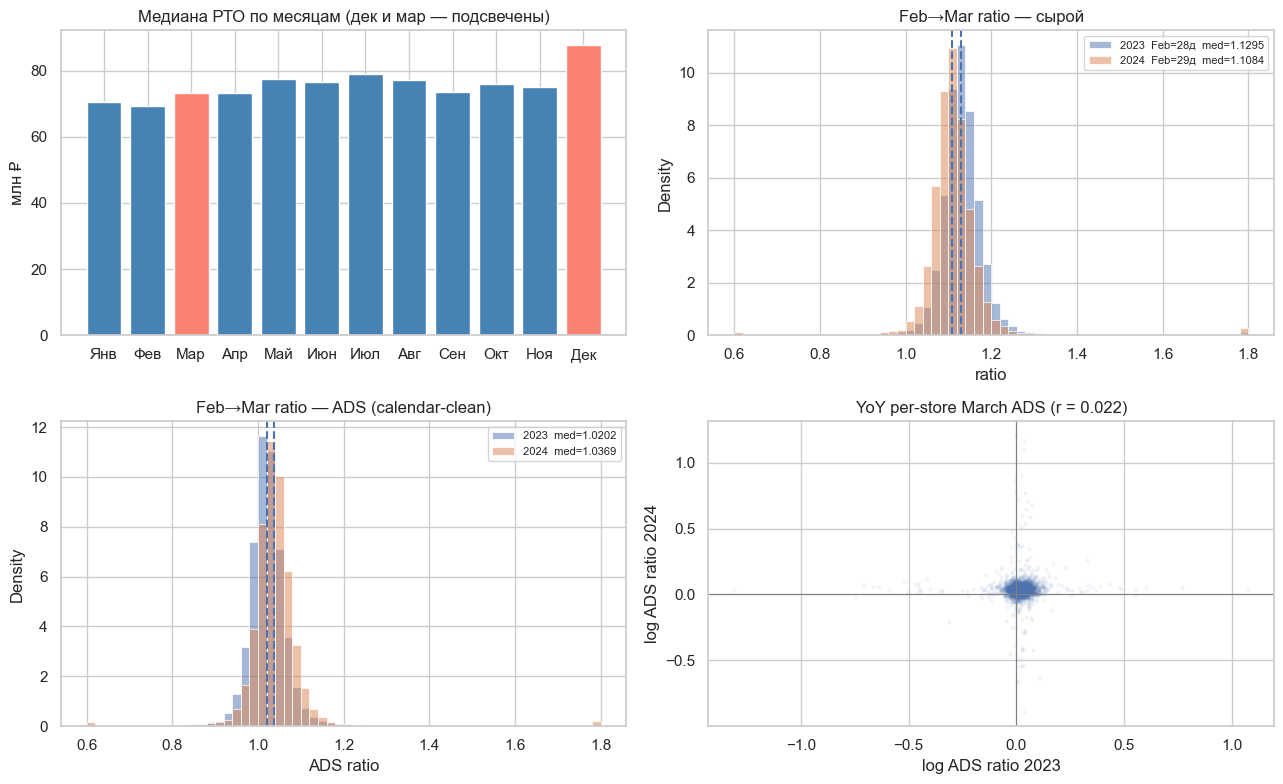

In [6]:
CITY = 'Населенный пункт'
MN   = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Сезонность — декабрь пик, март — скачок от февраля
med = df.groupby(df['ts'].dt.month)['rto'].median().reindex(range(1, 13)) / 1e6
clr = ['salmon' if m in (3, 12) else 'steelblue' for m in range(1, 13)]
axes[0, 0].bar(MN, med.values, color=clr)
axes[0, 0].set(title='Медиана РТО по месяцам (дек и мар — подсвечены)', ylabel='млн ₽')

# Raw Feb→Mar ratio — считаем медианы для аннотации
raw_means = {}
for yr, lbl in [(2023, '2023  Feb=28д'), (2024, '2024  Feb=29д')]:
    f = df[df['ts'] == f'{yr}-02-01'].set_index('new_id')['rto']
    m = df[df['ts'] == f'{yr}-03-01'].set_index('new_id')['rto']
    cx = f.index.intersection(m.index)
    ratio = (m[cx] / f[cx])
    raw_means[yr] = ratio.median()
    sns.histplot(ratio.clip(0.6, 1.8), bins=60, alpha=0.5,
                 label=f'{lbl}  med={ratio.median():.4f}', stat='density', ax=axes[0, 1])
    axes[0, 1].axvline(ratio.median(), lw=1.5, ls='--')
axes[0, 1].set(title='Feb→Mar ratio — сырой', xlabel='ratio')
axes[0, 1].legend(fontsize=8)

# ADS-нормализованный ratio — медианы должны поменять знак разницы
ads_means = {}
for yr, lbl in [(2023, '2023'), (2024, '2024')]:
    f = df[df['ts'] == f'{yr}-02-01'].set_index('new_id')['rto']
    m = df[df['ts'] == f'{yr}-03-01'].set_index('new_id')['rto']
    fd = float(pd.Timestamp(f'{yr}-02-01').days_in_month)
    cx = f.index.intersection(m.index)
    ratio = (m[cx] / 31) / (f[cx] / fd)
    ads_means[yr] = ratio.median()
    sns.histplot(ratio.clip(0.6, 1.8), bins=60, alpha=0.5,
                 label=f'{lbl}  med={ratio.median():.4f}', stat='density', ax=axes[1, 0])
    axes[1, 0].axvline(ratio.median(), lw=1.5, ls='--')
axes[1, 0].set(title='Feb→Mar ratio — ADS (calendar-clean)', xlabel='ADS ratio')
axes[1, 0].legend(fontsize=8)
print(f'Сырой:  2023={raw_means[2023]:.4f}  2024={raw_means[2024]:.4f}       delta={raw_means[2024]-raw_means[2023]:+.4f}  (2024 < 2023 из-за длинного фев)')
print(f'ADS:    2023={ads_means[2023]:.4f}  2024={ads_means[2024]:.4f}       delta={ads_means[2024]-ads_means[2023]:+.4f}  (знак поменялся — 2024 > 2023)')
print(f'Вывод: ADS убирает календарный артефакт. Разница ~2% — реальный экономический рост.')

# YoY per-store корреляция
f23 = df[df['ts'] == '2023-02-01'].set_index('new_id')['rto']
m23 = df[df['ts'] == '2023-03-01'].set_index('new_id')['rto']
f24 = df[df['ts'] == '2024-02-01'].set_index('new_id')['rto']
m24 = df[df['ts'] == '2024-03-01'].set_index('new_id')['rto']
b   = f23.index.intersection(m23.index).intersection(f24.index).intersection(m24.index)
r23 = np.log((m23[b] / 31) / (f23[b] / 28))
r24 = np.log((m24[b] / 31) / (f24[b] / 29))
sx  = np.random.choice(len(r23), 3000, replace=False)
corr = float(pd.Series(r23.values).corr(pd.Series(r24.values)))
axes[1, 1].scatter(r23.values[sx], r24.values[sx], alpha=0.05, s=4)
axes[1, 1].axhline(0, color='gray', lw=0.8)
axes[1, 1].axvline(0, color='gray', lw=0.8)
axes[1, 1].set(title=f'YoY per-store March ADS (r = {corr:.3f})',
               xlabel='log ADS ratio 2023', ylabel='log ADS ratio 2024')

plt.tight_layout()
plt.show()

## 4. Признаки и модель

**Таргет:** `log(ADS_t / ADS_{t-1})` — лог-прирост среднедневных продаж.
**Признаки:** лаги ADS-моментума `r1…r6`, скользящие средние, волатильность, соцгео.
**Калибровка:** `mean(pred / feb) = L = 1.138`, амплитуда `a = 0.94`.

In [7]:
STATIC_CAT = ['Дата открытия, категориальный',
              'Торговая площадь, категориальный',
              'Населенный пункт', 'Регион']
STATIC_NUM = ['Рабочие часы в день', 'Численность населения',
              'Количество домохозяйств', 'Трафик пеший, в час',
              'Трафик авто, в час',
              'Маркетплейсы, доставки, постаматы (100 м)',
              'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
              'Остановки (300 м)', 'Продуктовые магазины (500 м)',
              'Пятерочки (500 м)', 'Количество касс',
              'Флаг алкогольной лицензии']
TARGET_TS = pd.Timestamp('2025-03-01')
BASE_TS   = pd.Timestamp('2025-02-01')
L, A = 1.138, 0.94

def ads_feats(long):
    long = long.sort_values(['new_id', 'ts']).reset_index(drop=True)
    dim  = long['ts'].dt.days_in_month.astype(float)
    long['log_ads'] = np.log(long['rto'] / dim)
    g = long.groupby('new_id', sort=False)
    long['r'] = long['log_ads'] - g['log_ads'].shift(1)
    for k in range(1, 7): long[f'r{k}'] = g['r'].shift(k)
    long['rmean3'] = g['r'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    long['rmean6'] = g['r'].shift(1).rolling(6).mean().reset_index(level=0, drop=True)
    long['rstd6']  = g['r'].shift(1).rolling(6).std().reset_index(level=0, drop=True)
    long['log_base']  = g['log_ads'].shift(1)
    long['city_freq'] = long.groupby(CITY)['new_id'].transform('nunique').astype(float)
    long['month'] = long['ts'].dt.month
    return long

## 5. Валидация: March-2024 holdout
Обучение на данных до февраля 2024, прогноз на март 2024.

In [8]:
H_TS   = pd.Timestamp('2024-03-01')
H_BASE = pd.Timestamp('2024-02-01')
stub_h = df[df['ts'] == H_BASE].copy()
stub_h['ts'] = H_TS; stub_h['rto'] = np.nan
lh = ads_feats(pd.concat([df[df['ts'] <= H_BASE], stub_h], ignore_index=True))
CAT3 = [c for c in STATIC_CAT if c != CITY]
for c in CAT3: lh[c] = lh[c].astype('category').cat.codes
FEATS = (['month','r1','r2','r3','r4','r5','r6',
          'rmean3','rmean6','rstd6','log_base','city_freq'] + CAT3 + STATIC_NUM)
cidx  = [FEATS.index(c) for c in ['month'] + CAT3]
tr_h  = lh[(lh['ts'] < H_TS) & lh['r'].notna() & lh['r1'].notna()]
te_h  = lh[lh['ts'] == H_TS].copy()
act_h = df[df['ts'] == H_TS].set_index('new_id')['rto'].reindex(te_h['new_id']).values
feb_h = df[df['ts'] == H_BASE].set_index('new_id')['rto'].reindex(te_h['new_id']).values
m_h = HistGradientBoostingRegressor(
    loss='absolute_error', max_depth=8, learning_rate=0.05,
    max_iter=400, min_samples_leaf=40, l2_regularization=0.1,
    categorical_features=cidx, early_stopping=True, random_state=0)
m_h.fit(tr_h[FEATS], tr_h['r'])
rh     = m_h.predict(te_h[FEATS])
mu     = rh.mean(); tilt = np.exp(mu + A * (rh - mu))
pred_h = feb_h * tilt * (L / tilt.mean())
ape    = np.abs(pred_h - act_h) / act_h * 100
print(f'MAPE={ape.mean():.3f}%  P50={np.median(ape):.3f}%  P95={np.percentile(ape, 95):.1f}%')

MAPE=4.311%  P50=2.955%  P95=10.4%


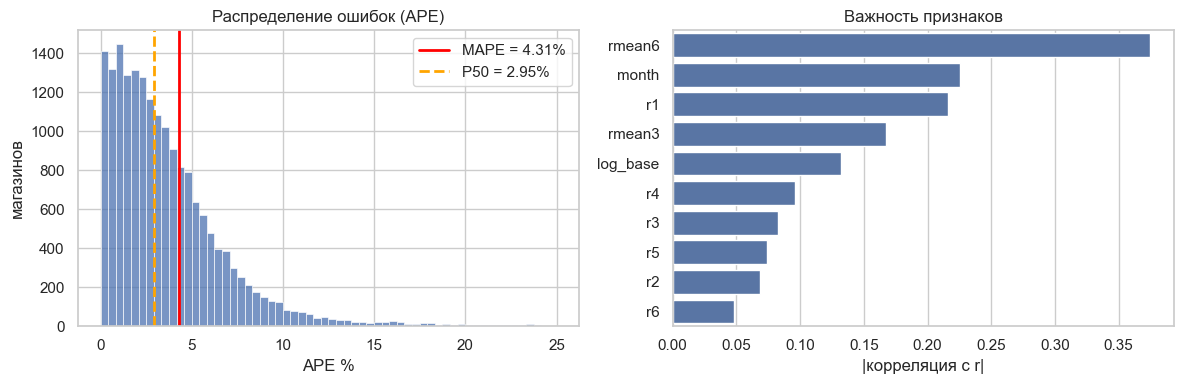

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(ape[ape < 25], bins=60, ax=axes[0])
axes[0].axvline(ape.mean(), color='red', lw=2, label=f'MAPE = {ape.mean():.2f}%')
axes[0].axvline(np.median(ape), color='orange', lw=2, ls='--',
                label=f'P50 = {np.median(ape):.2f}%')
axes[0].set(title='Распределение ошибок (APE)', xlabel='APE %', ylabel='магазинов')
axes[0].legend()

imp = (tr_h[FEATS + ['r']].corr()['r'].drop('r').abs()
       .sort_values(ascending=False).head(10))
sns.barplot(x=imp.values, y=imp.index, ax=axes[1])
axes[1].set(title='Важность признаков', xlabel='|корреляция с r|', ylabel='')

plt.tight_layout()
plt.show()

## 6. Разработка решения

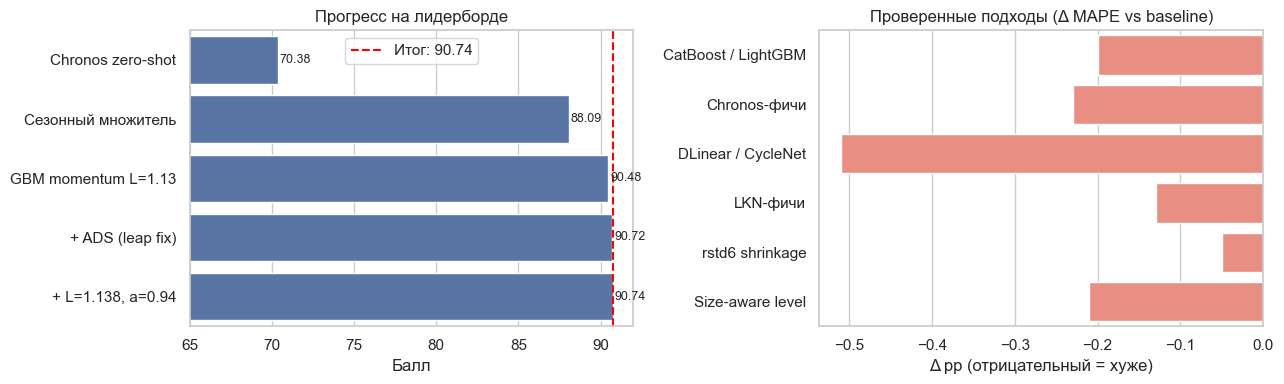

In [10]:
rows = [
    ('Chronos zero-shot',    70.38),
    ('Сезонный множитель',   88.09),
    ('GBM momentum L=1.13',  90.48),
    ('+ ADS (leap fix)',      90.72),
    ('+ L=1.138, a=0.94',    90.74),
]
failed = [
    ('CatBoost / LightGBM',  -0.20),
    ('Chronos-фичи',          -0.23),
    ('DLinear / CycleNet',    -0.51),
    ('LKN-фичи',              -0.13),
    ('rstd6 shrinkage',       -0.05),
    ('Size-aware level',      -0.21),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names, scores = zip(*rows)
sns.barplot(x=scores, y=names, ax=axes[0])
axes[0].axvline(90.74, color='red', lw=1.5, ls='--', label='Итог: 90.74')
for i, s in enumerate(scores): axes[0].text(s + 0.1, i, str(s), va='center', fontsize=9)
axes[0].set(xlim=(65, 92), title='Прогресс на лидерборде', xlabel='Балл')
axes[0].legend()

fn, fd = zip(*failed)
sns.barplot(x=fd, y=fn, color='salmon', ax=axes[1])
axes[1].axvline(0, color='gray', lw=1)
axes[1].set(title='Проверенные подходы (Δ MAPE vs baseline)',
            xlabel='Δ pp (отрицательный = хуже)')

plt.tight_layout()
plt.show()

## 7. Итоговый прогноз → `test.csv`

In [11]:
stub = df[df['ts'] == BASE_TS].copy()
stub['ts'] = TARGET_TS; stub['rto'] = np.nan
lp = ads_feats(pd.concat([df, stub], ignore_index=True))
CAT3p = [c for c in STATIC_CAT if c != CITY]
for c in CAT3p: lp[c] = lp[c].astype('category').cat.codes
FP  = (['month','r1','r2','r3','r4','r5','r6',
        'rmean3','rmean6','rstd6','log_base','city_freq'] + CAT3p + STATIC_NUM)
cip = [FP.index(c) for c in ['month'] + CAT3p]
tr  = lp[(lp['ts'] < TARGET_TS) & lp['r'].notna() & lp['r1'].notna()]
te  = lp[lp['ts'] == TARGET_TS].copy()
m = HistGradientBoostingRegressor(
    loss='absolute_error', max_depth=8, learning_rate=0.05,
    max_iter=400, min_samples_leaf=40, l2_regularization=0.1,
    categorical_features=cip, early_stopping=True, random_state=0)
m.fit(tr[FP], tr['r'])
rhat = m.predict(te[FP])
feb  = df[df['ts'] == BASE_TS].set_index('new_id')['rto'].reindex(te['new_id']).values
mu   = rhat.mean(); tilt = np.exp(mu + A * (rhat - mu))
pred = feb * tilt * (L / tilt.mean())
print(f'iters={m.n_iter_}  mean_ratio={(pred / feb).mean():.5f}  (ожидается {L})')

iters=400  mean_ratio=1.13800  (ожидается 1.138)


In [12]:
sub = pd.DataFrame({'new_id': te['new_id'].astype(int), 'rto': pred})
sub = sub.sort_values('new_id').reset_index(drop=True)
assert len(sub) == 18657 and sub['rto'].isna().sum() == 0
sub.to_csv('test.csv', index=False)
print(f'test.csv: {len(sub):,} строк · {Path("test.csv").stat().st_size // 1024} KB')
sub.head(5)

test.csv: 18,657 строк · 451 KB


,new_id,rto
0,0,9.309311e+07
1,1,4.470200e+07
2,2,9.017475e+07
3,3,6.903936e+07
4,4,8.258469e+07


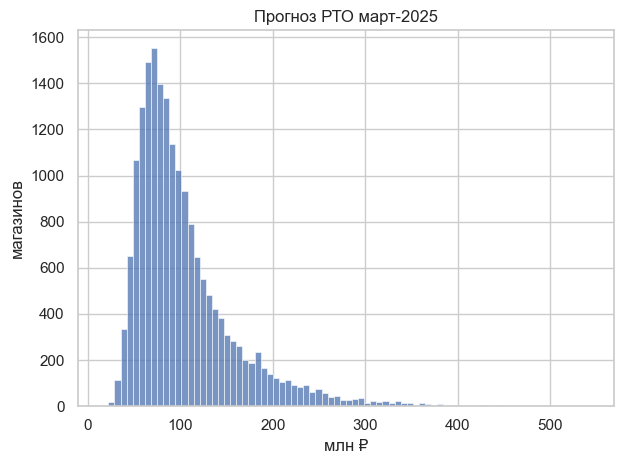

In [13]:
sns.histplot(pred / 1e6, bins=80)
plt.title('Прогноз РТО март-2025')
plt.xlabel('млн ₽'); plt.ylabel('магазинов')
plt.tight_layout()
plt.show()